<a href="https://colab.research.google.com/github/murtazaarsh7/ml_in_summers2026/blob/main/feature_scaling_Standardization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import pandas as pd
import numpy as np


In [63]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


In [28]:
df=pd.read_csv('/content/Social_Network_Ads.csv')

In [29]:
df.sample(5)

,User ID,Gender,Age,EstimatedSalary,Purchased
374,15793890,Female,37,80000,0
377,15800215,Female,42,53000,0
213,15657163,Male,35,58000,0
17,15617482,Male,45,26000,1
295,15725794,Female,36,63000,0


In [30]:
df=df.iloc[:,2:]

In [31]:
df.shape

(400, 3)

In [32]:
df.sample(6
          )

,Age,EstimatedSalary,Purchased
237,37,80000,0
47,27,54000,0
316,54,104000,1
209,46,22000,0
345,41,63000,0
395,46,41000,1


In [101]:
X_train,X_test,y_train,y_test=train_test_split(df.drop('Purchased',axis=1),df['Purchased'],test_size=0.3,random_state=0)
X_train.shape,X_test.shape

((280, 2), (120, 2))

In [34]:

import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='Age', ylabel='EstimatedSalary'>

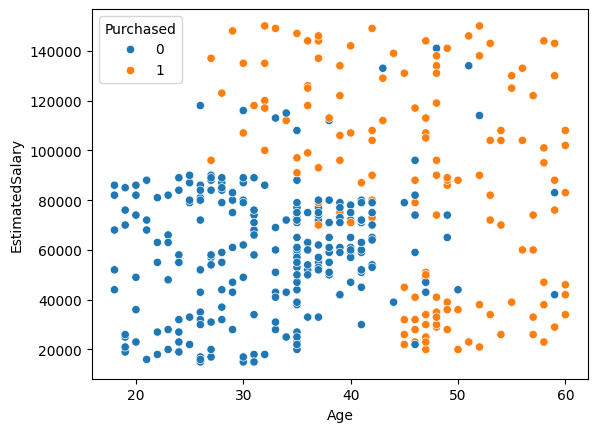

In [35]:
sns.scatterplot(x=df['Age'],y=df['EstimatedSalary'],hue=df['Purchased'])

In [102]:
scaler=StandardScaler()
scaler.fit(X_train)
X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)
X_train_scaled

array([[-1.1631724 , -1.5849703 ],
       [ 2.17018137,  0.93098672],
       [ 0.0133054 ,  1.22017719],
       [ 0.20938504,  1.07558195],
       [ 0.40546467, -0.48604654],
       [-0.28081405, -0.31253226],
       [ 0.99370357, -0.8330751 ],
       [ 0.99370357,  1.8563962 ],
       [ 0.0133054 ,  1.24909623],
       [-0.86905295,  2.26126285],
       [-1.1631724 , -1.5849703 ],
       [ 2.17018137, -0.80415605],
       [-1.35925203, -1.46929411],
       [ 0.40546467,  2.2901819 ],
       [ 0.79762394,  0.75747245],
       [-0.96709276, -0.31253226],
       [ 0.11134522,  0.75747245],
       [-0.96709276,  0.55503912],
       [ 0.30742485,  0.06341534],
       [ 0.69958412, -1.26686079],
       [-0.47689368, -0.0233418 ],
       [-1.7514113 ,  0.3526058 ],
       [-0.67297331,  0.12125343],
       [ 0.40546467,  0.29476771],
       [-0.28081405,  0.06341534],
       [-0.47689368,  2.2901819 ],
       [ 0.20938504,  0.03449629],
       [ 1.28782302,  2.20342476],
       [ 0.79762394,

In [90]:
scaler.mean_

array([3.78642857e+01, 6.98071429e+04])

In [103]:
X_train_scaled=pd.DataFrame(X_train_scaled,columns=X_train.columns)
X_test_scaled=pd.DataFrame(X_test_scaled,columns=X_test.columns)
X_train_scaled

,Age,EstimatedSalary
0,-1.163172,-1.584970
1,2.170181,0.930987
2,0.013305,1.220177
3,0.209385,1.075582
4,0.405465,-0.486047
...,...,...
275,0.993704,-1.151185
276,-0.869053,-0.775237
277,-0.182774,-0.514966
278,-1.065133,-0.457127


In [50]:
np.round(X_train.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,37.9,69807.1
std,10.2,34641.2
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,88000.0
max,60.0,150000.0


In [51]:
np.round(X_train_scaled.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


Text(0, 0.5, 'EstimatedSalary')

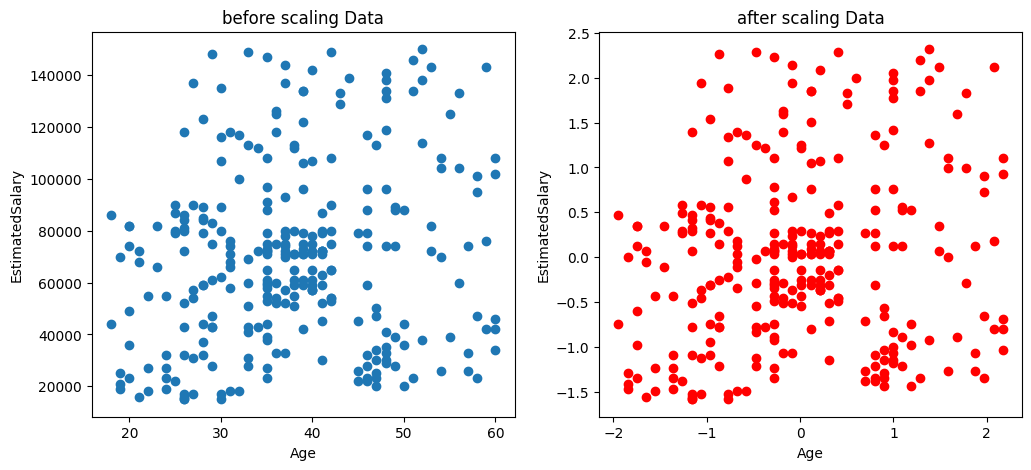

In [60]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))
ax1.scatter(X_train['Age'],X_train['EstimatedSalary'])
ax1.set_title('before scaling Data')
ax1.set_xlabel('Age')
ax1.set_ylabel('EstimatedSalary')
ax2.scatter(X_train_scaled['Age'],X_train_scaled['EstimatedSalary'],c='r')
ax2.set_title('after scaling Data')
ax2.set_xlabel('Age')
ax2.set_ylabel('EstimatedSalary')


<Axes: title={'center': 'after scaling Data'}, xlabel='Age', ylabel='Density'>

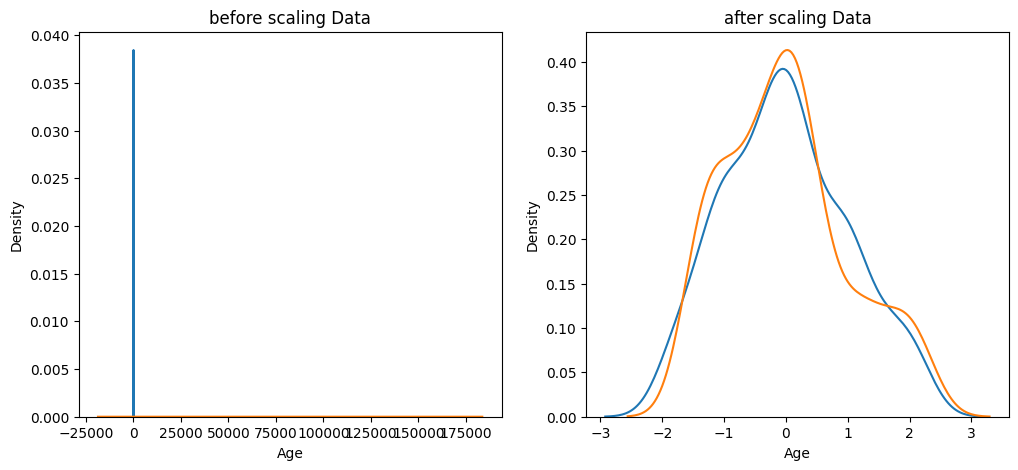

In [61]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))
#before scalinh
ax1.set_title('before scaling Data')
sns.kdeplot(X_train['Age'],ax=ax1)
sns.kdeplot(X_train['EstimatedSalary'],ax=ax1)
#after scaling
ax2.set_title('after scaling Data')
sns.kdeplot(X_train_scaled['Age'],ax=ax2)
sns.kdeplot(X_train_scaled['EstimatedSalary'],ax=ax2)


In [104]:
lr=LogisticRegression()
lr.fit(X_train,y_train)
y_pred=lr.predict(X_test)

accuracy_score(y_test,y_pred)

0.875

In [105]:
lr_scaled=LogisticRegression()
lr_scaled.fit(X_train_scaled,y_train)
Y_pred_scaled=lr_scaled.predict(X_test_scaled)
accuracy_score(y_test,Y_pred_scaled)


0.8666666666666667

In [97]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier()
dt_scaled=DecisionTreeClassifier()


In [99]:
dt.fit(X_train,y_train)
dt_scaled.fit(X_train_scaled,y_train)

DecisionTreeClassifier()

In [100]:
dt_pred=dt.predict(X_test)
dt_scaled_pred=dt_scaled.predict(X_test_scaled)
print('Actual',accuracy_score(y_test,dt_pred))
print('Scaled',accuracy_score(y_test,dt_scaled_pred))


Actual 0.875
Scaled 0.875
